# Kankor Retrieval Benchmark: `text-embedding-3-large`

This notebook is for the new canonical page corpus. It benchmarks:

- dense retrieval only, to isolate embedding quality
- hybrid retrieval, to measure the real production stack with lexical retrieval and RRF
- hybrid + reranker, to check whether reranking improves early precision on the retrieved pool

Expected index artifacts:

- `data/index/kankor_openai_full/index.faiss`
- `data/index/kankor_openai_full/metadata.jsonl`
- `data/index/kankor_openai_full/chapter_index.jsonl`
- `data/index/kankor_openai_full/topic_index.jsonl`


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'packages' / 'rag_core' / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / 'packages' / 'rag_core' / 'src'))

from rag_core.eval.retrieval_benchmark import (
    benchmark_dense_retrieval,
    benchmark_hybrid_retrieval,
    benchmark_hybrid_reranked_retrieval,
    load_qrels,
    load_query_suite,
)
from rag_core.impl.embeddings_openai import OpenAIEmbedder
from rag_core.impl.reranker_onnx import ONNXSequenceClassificationReranker
from rag_core.impl.vector_faiss import FaissVectorStore
from rag_core.rag.retrieval import DenseRetriever, LexicalRetriever, PageRetrievalEngine, RRFFusionPolicy


In [2]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path=REPO_ROOT / 'docker' / '.env')
api_key = os.getenv("OPENAI_API_KEY")

In [3]:
INDEX_DIR = REPO_ROOT / 'data' / 'index' / 'kankor_openai_full'
INDEX_PATH = INDEX_DIR / 'index.faiss'
DOCSTORE_PATH = INDEX_DIR / 'metadata.jsonl'
QUERY_SUITE_NAME = 'chunking_pages_v2'
QUERY_SUITE_PATH = REPO_ROOT / 'data' / 'query_suites' / f'{QUERY_SUITE_NAME.replace("_v2", "")}_suite_v2.jsonl'
QRELS_PATH = REPO_ROOT / 'data' / 'query_suites' / f'{QUERY_SUITE_NAME.replace("_v2", "")}_qrels_v2.jsonl'

OPENAI_API_KEY = os.getenv('RAG_OPENAI_API_KEY') or os.getenv('OPENAI_API_KEY')
assert OPENAI_API_KEY, 'Set RAG_OPENAI_API_KEY or OPENAI_API_KEY before running the notebook.'

EMBEDDING_MODEL_ID = 'text-embedding-3-large'
RUN_RERANKER = False
K_VALUES = (1, 3, 5, 10)
DENSE_MIN_SCORE = 0.15
LEXICAL_MIN_SCORE = 0.01
RRF_K = 20
QUERY_BATCH_SIZE = 64
RERANKER_MODEL_ID = os.getenv('RAG_RERANKER_MODEL_ID') or 'onnx-community/gte-multilingual-reranker-base'
RERANKER_MODEL_REVISION = os.getenv('RAG_RERANKER_MODEL_REVISION') or '5807a06097ed1e68331fec2201751ccaf356d96b'
RERANKER_MAX_LENGTH = int(os.getenv('RAG_RERANKER_MAX_LENGTH') or '256')
RERANKER_BATCH_SIZE = int(os.getenv('RAG_RERANKER_BATCH_SIZE') or '8')
RERANKER_CANDIDATE_POOL_SIZE = int(os.getenv('RAG_RERANKER_CANDIDATE_POOL_SIZE') or '8')

assert INDEX_PATH.exists(), f'Missing index: {INDEX_PATH}'
assert DOCSTORE_PATH.exists(), f'Missing docstore: {DOCSTORE_PATH}'
assert QUERY_SUITE_PATH.exists(), f'Missing query suite: {QUERY_SUITE_PATH}'
assert QRELS_PATH.exists(), f'Missing qrels: {QRELS_PATH}'


In [4]:
vector_store = FaissVectorStore.load(INDEX_PATH, DOCSTORE_PATH)
embedder = OpenAIEmbedder(model_name=EMBEDDING_MODEL_ID, api_key=OPENAI_API_KEY)

dense_retriever = DenseRetriever(
    embedder=embedder,
    vector_store=vector_store,
    min_score=DENSE_MIN_SCORE,
)
lexical_retriever = LexicalRetriever(
    vector_store=vector_store,
    min_score=LEXICAL_MIN_SCORE,
)
fusion_policy = RRFFusionPolicy(rrf_k=RRF_K)
hybrid_engine = PageRetrievalEngine(
    dense_retriever=dense_retriever,
    lexical_retriever=lexical_retriever,
    fusion_policy=fusion_policy,
)
reranker_probe_error = None
reranker = None
if RUN_RERANKER:
    reranker = ONNXSequenceClassificationReranker(
        model_name=RERANKER_MODEL_ID,
        model_revision=RERANKER_MODEL_REVISION,
        max_length=RERANKER_MAX_LENGTH,
        batch_size=RERANKER_BATCH_SIZE,
    )
    try:
        reranker.warmup()
    except Exception as exc:
        reranker_probe_error = f'{type(exc).__name__}: {exc}'

queries = load_query_suite(
    QUERY_SUITE_PATH,
    allowed_intents={'grounded_textbook', 'practice_generation'},
)
qrels_by_query = load_qrels(QRELS_PATH)

{
    'vector_store_size': vector_store.size,
    'query_count': len(queries),
    'qrels_count': len(qrels_by_query),
    'embedding_model': EMBEDDING_MODEL_ID,
    'run_reranker': RUN_RERANKER,
    'reranker_model': RERANKER_MODEL_ID,
    'reranker_candidate_pool_size': RERANKER_CANDIDATE_POOL_SIZE,
    'reranker_ready': (not RUN_RERANKER) or reranker_probe_error is None,
    'reranker_probe_error': reranker_probe_error,
}


{'vector_store_size': 7738,
 'query_count': 9111,
 'qrels_count': 9111,
 'embedding_model': 'text-embedding-3-large',
 'run_reranker': False,
 'reranker_model': 'onnx-community/gte-multilingual-reranker-base',
 'reranker_candidate_pool_size': 8,
 'reranker_ready': True,
 'reranker_probe_error': None}

In [5]:
queries_small = queries[:2]

In [6]:
dense_results = benchmark_dense_retrieval(
    queries=queries,
    qrels_by_query=qrels_by_query,
    dense_retriever=dense_retriever,
    k_values=K_VALUES,
    query_batch_size=QUERY_BATCH_SIZE,
)

hybrid_results = benchmark_hybrid_retrieval(
    queries=queries,
    qrels_by_query=qrels_by_query,
    retrieval_engine=hybrid_engine,
    k_values=K_VALUES,
    query_batch_size=QUERY_BATCH_SIZE,
)

hybrid_reranked_results = None
if RUN_RERANKER:
    assert reranker_probe_error is None, f'Reranker is not ready: {reranker_probe_error}'
    hybrid_reranked_results = benchmark_hybrid_reranked_retrieval(
        queries=queries,
        qrels_by_query=qrels_by_query,
        retrieval_engine=hybrid_engine,
        reranker=reranker,
        k_values=K_VALUES,
        reranker_candidate_pool_size=RERANKER_CANDIDATE_POOL_SIZE,
        query_batch_size=QUERY_BATCH_SIZE,
    )

dense_aggregate = pd.DataFrame.from_dict(dense_results['aggregate_by_k'], orient='index').set_index('k')
hybrid_aggregate = pd.DataFrame.from_dict(hybrid_results['aggregate_by_k'], orient='index').set_index('k')
comparison = dense_aggregate.add_prefix('dense_').join(hybrid_aggregate.add_prefix('hybrid_'))
if hybrid_reranked_results is not None:
    hybrid_reranked_aggregate = pd.DataFrame.from_dict(hybrid_reranked_results['aggregate_by_k'], orient='index').set_index('k')
    comparison = comparison.join(hybrid_reranked_aggregate.add_prefix('hybrid_reranked_'))
comparison


,dense_query_count_evaluated,dense_query_count_skipped_no_hits,dense_mean_hit_rate_at_k,dense_mean_recall_at_k,dense_mean_mrr_at_k,dense_mean_ndcg_at_k,hybrid_query_count_evaluated,hybrid_query_count_skipped_no_hits,hybrid_mean_hit_rate_at_k,hybrid_mean_recall_at_k,hybrid_mean_mrr_at_k,hybrid_mean_ndcg_at_k
k,,,,,,,,,,,,
1,9111,0,0.587312,0.458182,0.587312,0.587312,9111,0,0.473933,0.384151,0.473933,0.473933
3,9111,0,0.723411,0.613928,0.648429,0.452398,9111,0,0.692569,0.587477,0.574031,0.396930
5,9111,0,0.770607,0.671276,0.659196,0.478034,9111,0,0.748436,0.650971,0.586944,0.423722
10,9111,0,0.827132,0.738887,0.666892,0.502530,9111,0,0.806827,0.721545,0.594832,0.448576


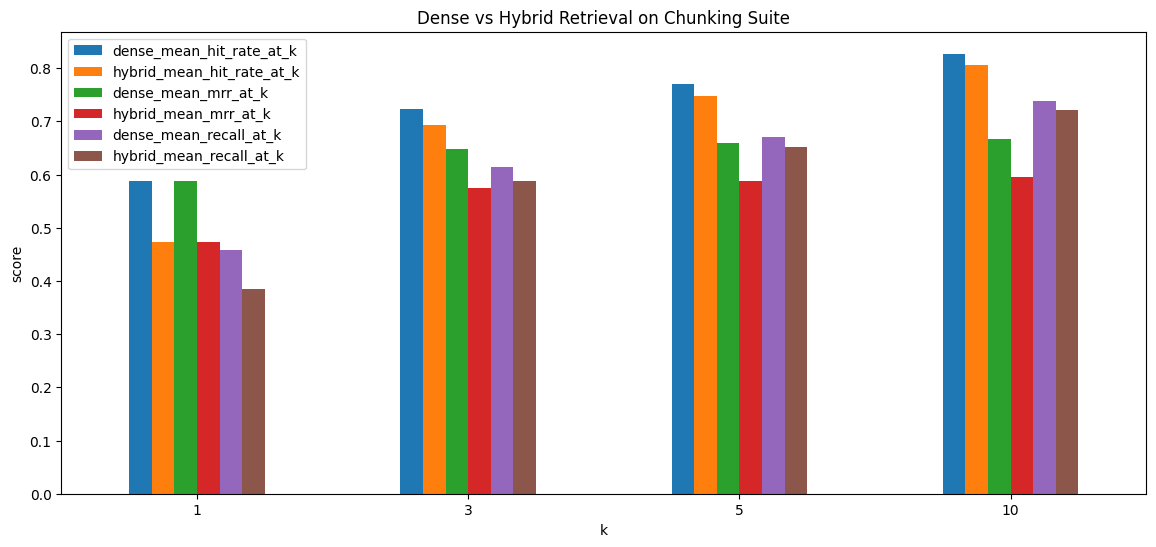

In [7]:
plot_columns = [
    'dense_mean_hit_rate_at_k',
    'hybrid_mean_hit_rate_at_k',
    'dense_mean_mrr_at_k',
    'hybrid_mean_mrr_at_k',
    'dense_mean_recall_at_k',
    'hybrid_mean_recall_at_k',
]
if RUN_RERANKER and 'hybrid_reranked_mean_hit_rate_at_k' in comparison.columns:
    plot_columns.extend([
        'hybrid_reranked_mean_hit_rate_at_k',
        'hybrid_reranked_mean_mrr_at_k',
        'hybrid_reranked_mean_recall_at_k',
    ])

comparison[plot_columns].plot(
    kind='bar',
    figsize=(14, 6),
    title='Dense vs Hybrid Retrieval on Chunking Suite' if not RUN_RERANKER else 'Dense vs Hybrid vs Hybrid + Reranker on Chunking Suite',
)
plt.ylabel('score')
plt.xticks(rotation=0)
plt.show()

In [8]:
analysis_results = hybrid_reranked_results if RUN_RERANKER and hybrid_reranked_results is not None else hybrid_results
analysis_per_query = pd.DataFrame(analysis_results['per_query'])
analysis_per_query['expected_subject'] = analysis_per_query['expected_subjects'].apply(lambda items: items[0] if items else '')

slice_summary = (
    analysis_per_query
    .groupby(['language', 'origin'], dropna=False)[['hit_rate_at_5', 'mrr_at_5', 'recall_at_5']]
    .mean()
    .sort_index()
)
slice_summary


,,hit_rate_at_5,mrr_at_5,recall_at_5
language,origin,,,
en,chunk_test,0.814620,0.571469,0.689002
fa,chunk_test,0.915048,0.807206,0.837833
ps,chunk_test,0.515640,0.382159,0.426078


In [9]:
analysis_retrieval_rows = analysis_results['retrieval_rows']
retrieval_lookup = {row['query_id']: row for row in analysis_retrieval_rows}

def preview_hits(query_id: str, limit: int = 5) -> pd.DataFrame:
    row = retrieval_lookup[query_id]
    hits = row.get('hits', [])[:limit]
    return pd.DataFrame(hits)

failures = analysis_per_query[analysis_per_query['hit_rate_at_5'] < 1.0].copy()
failures[['query_id', 'query', 'language', 'origin', 'expected_subject', 'first_relevant_rank_at_10']].head(20)


,query_id,query,language,origin,expected_subject,first_relevant_rank_at_10
1,chunk_v2_g10_dr_chemistry_q006_ps,په مقدمه کې کیمیا د کوم ډول علم په توګه معرفي ...,ps,chunk_test,chemistry,6.0
4,chunk_v2_g10_dr_chemistry_q007_ps,هغه یوناني فیلسوف چې په ۴۰۰ ق.م کې یې اټومي نظ...,ps,chunk_test,chemistry,NaN
7,chunk_v2_g10_dr_chemistry_q008_ps,د متن له مخې، ډالټن په کوم کال اټومي نظریه بنس...,ps,chunk_test,chemistry,NaN
10,chunk_v2_g10_dr_chemistry_q009_ps,د اټوم د اندازې په برخه کې د اټوم نږدې قطر څوم...,ps,chunk_test,chemistry,NaN
16,chunk_v2_g10_dr_chemistry_q011_ps,هغه د الکترون برقي چارج چې میلیکان ټاکلی، کوم دی؟,ps,chunk_test,chemistry,NaN
22,chunk_v2_g10_dr_chemistry_q013_ps,د رادرفورډ د سرو زرو د پاڼې په تجربه کې د ذرو ...,ps,chunk_test,chemistry,NaN
25,chunk_v2_g10_dr_chemistry_q014_ps,موزلي اټومي شمېر په کوم سمبول ښودلی دی؟,ps,chunk_test,chemistry,NaN
28,chunk_v2_g10_dr_chemistry_q015_ps,د متن له مخې، اټومي شمېر د څه شي سره برابر دی؟,ps,chunk_test,chemistry,NaN
34,chunk_v2_g10_dr_chemistry_q017_ps,د نوکلیویدونو په نښه کولو کې د کتلي شمېر د سمب...,ps,chunk_test,chemistry,NaN
40,chunk_v2_g10_dr_chemistry_q019_ps,د بالمر د لړۍ په تشریح کې دا کرښې په کومه ساحه...,ps,chunk_test,chemistry,NaN


In [11]:
from IPython.display import display

subject_failure_summary = (
    analysis_per_query
    .assign(
        expected_subject=lambda df: df['expected_subject'].replace('', 'unknown'),
        failed_at_5=lambda df: df['hit_rate_at_5'] < 1.0,
        miss_top10=lambda df: df['first_relevant_rank_at_10'].isna(),
    )
    .groupby('expected_subject', dropna=False)
    .agg(
        query_count=('query_id', 'size'),
        fail_count_at_5=('failed_at_5', 'sum'),
        fail_rate_at_5=('failed_at_5', 'mean'),
        miss_top10_count=('miss_top10', 'sum'),
        miss_top10_rate=('miss_top10', 'mean'),
        mean_hit_rate_at_5=('hit_rate_at_5', 'mean'),
        mean_mrr_at_5=('mrr_at_5', 'mean'),
        mean_recall_at_5=('recall_at_5', 'mean'),
    )
    .sort_values(['fail_rate_at_5', 'miss_top10_rate', 'query_count'], ascending=[False, False, False])
)

subject_language_failure_summary = (
    analysis_per_query
    .assign(
        expected_subject=lambda df: df['expected_subject'].replace('', 'unknown'),
        failed_at_5=lambda df: df['hit_rate_at_5'] < 1.0,
        miss_top10=lambda df: df['first_relevant_rank_at_10'].isna(),
    )
    .groupby(['expected_subject', 'language'], dropna=False)
    .agg(
        query_count=('query_id', 'size'),
        fail_rate_at_5=('failed_at_5', 'mean'),
        miss_top10_rate=('miss_top10', 'mean'),
        mean_hit_rate_at_5=('hit_rate_at_5', 'mean'),
        mean_mrr_at_5=('mrr_at_5', 'mean'),
        mean_recall_at_5=('recall_at_5', 'mean'),
    )
    .sort_values(['fail_rate_at_5', 'miss_top10_rate', 'query_count'], ascending=[False, False, False])
)

display(subject_failure_summary)
display(subject_language_failure_summary)


,query_count,fail_count_at_5,fail_rate_at_5,miss_top10_count,miss_top10_rate,mean_hit_rate_at_5,mean_mrr_at_5,mean_recall_at_5
expected_subject,,,,,,,,
pashto,600,210,0.350000,149,0.248333,0.650000,0.474944,0.519167
civic_education,891,311,0.349046,274,0.307520,0.650954,0.500486,0.570146
tafseer,900,305,0.338889,222,0.246667,0.661111,0.480685,0.546111
dari,900,292,0.324444,223,0.247778,0.675556,0.502130,0.524444
geology,300,84,0.280000,64,0.213333,0.720000,0.539944,0.621667
history,1095,258,0.235616,196,0.178995,0.764384,0.605723,0.692237
geography,1140,243,0.213158,194,0.170175,0.786842,0.603319,0.683333
islamic_studies,1800,361,0.200556,268,0.148889,0.799444,0.658315,0.711389
chemistry,285,55,0.192982,42,0.147368,0.807018,0.625673,0.661404


,,query_count,fail_rate_at_5,miss_top10_rate,mean_hit_rate_at_5,mean_mrr_at_5,mean_recall_at_5
expected_subject,language,,,,,,
civic_education,ps,297,0.828283,0.771044,0.171717,0.100730,0.126263
geology,ps,100,0.660000,0.590000,0.340000,0.224500,0.265000
dari,ps,300,0.636667,0.543333,0.363333,0.220000,0.263333
tafseer,ps,300,0.566667,0.473333,0.433333,0.300500,0.351667
pashto,fa,200,0.540000,0.425000,0.460000,0.264917,0.350000
geography,ps,380,0.500000,0.444737,0.500000,0.339605,0.381579
history,ps,365,0.473973,0.402740,0.526027,0.383059,0.463014
chemistry,ps,95,0.452632,0.378947,0.547368,0.379649,0.378947
pashto,en,200,0.450000,0.300000,0.550000,0.331750,0.385000


In [10]:
failures.shape


(2292, 32)

In [ ]:
#BUILD_COMMAND = """set -a; source docker/.env; set +a; \
#PYTHONPATH=packages/rag_core/src \
#conda run -n kankor-rag python scripts/build_index.py \
#  --corpus-root data/new_corpus \
#  --frontmatter-toc-path data/new_corpus/frontmatter_toc_normalized_manual_4.jsonl \
#  --output-dir data/index/kankor_openai_full \
#  --embedding-backend openai \
#  --openai-embedding-model-id text-embedding-3-large \
#  --embedding-batch-size 64 \
#  --corpus-version kankor-corpus@openai-te3l-v1"""

#print(BUILD_COMMAND)
